# Visual-Language Navigation for Legged Robots using RGB Images
## CS 691 Course Project 

In [1]:
import random, json, functools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm
 
EMBODIMENT = "Legged Robot"
CKPT       = "./best_mlp_simple.pt"
EMBED_VAL  = "./val_embeddings_simple.pt"
VAL_SPLIT  = 0.2
SEED       = 42
N_SHOW     = 6
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

goal_mean = torch.tensor([0.4935, 0.4728], dtype=torch.float32)
goal_std  = torch.tensor([0.2151, 0.1108], dtype=torch.float32)
 
print("Loading NaviTrace validation split...")
dataset = load_dataset("leggedrobotics/navitrace")

val_split_samples = []
for s in tqdm(list(dataset["validation"]), desc="Filtering"):
    gt = s["ground_truth"].get(EMBODIMENT)
    if gt is not None and len(gt) > 0:
        val_split_samples.append(s)
print(f"Loaded {len(val_split_samples)} samples")
 
random.seed(SEED)
random.shuffle(val_split_samples)
n_val       = int(len(val_split_samples) * VAL_SPLIT)
val_samples = val_split_samples[:n_val]
print(f"Val samples : {len(val_samples)}")
 
trace_lengths = [
    len(t) for s in val_samples
    for t in s["ground_truth"][EMBODIMENT]
]
N = int(np.median(trace_lengths))
print(f"N waypoints : {N}")
 
print("Loading val embeddings...")
val_emb   = torch.load(EMBED_VAL, weights_only=False)
val_joint = torch.cat([val_emb["img_emb"], val_emb["txt_emb"]], dim=-1)
print(f"Val joint : {val_joint.shape}")
 
class NavigationMLP(nn.Module):
    def __init__(self, N):
        super().__init__()
        self.N = N
        self.shared = nn.Sequential(
            nn.Linear(1024, 256), nn.ReLU(), nn.Dropout(0.15)
        )
        self.goal_head = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 2)
        )
        self.trace_head = nn.Sequential(
            nn.Linear(258, 128), nn.ReLU(),
            nn.Dropout(0.15), nn.Linear(128, N * 2), nn.Sigmoid()
        )

    def forward(self, x):
        h = self.shared(x)
        g = self.goal_head(h)
        t = self.trace_head(torch.cat([h, g.detach()], dim=-1))
        return g, t.view(-1, self.N, 2)

model = NavigationMLP(N).to(DEVICE)
model.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from {CKPT}")

/home/arif/miniconda3/envs/vln/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading NaviTrace validation split...


Filtering: 100%|██████████████████████████| 502/502 [00:00<00:00, 980689.62it/s]

Loaded 501 samples
Val samples : 100
N waypoints : 9
Loading val embeddings...
Val joint : torch.Size([100, 1024])
Model loaded from ./best_mlp_simple.pt


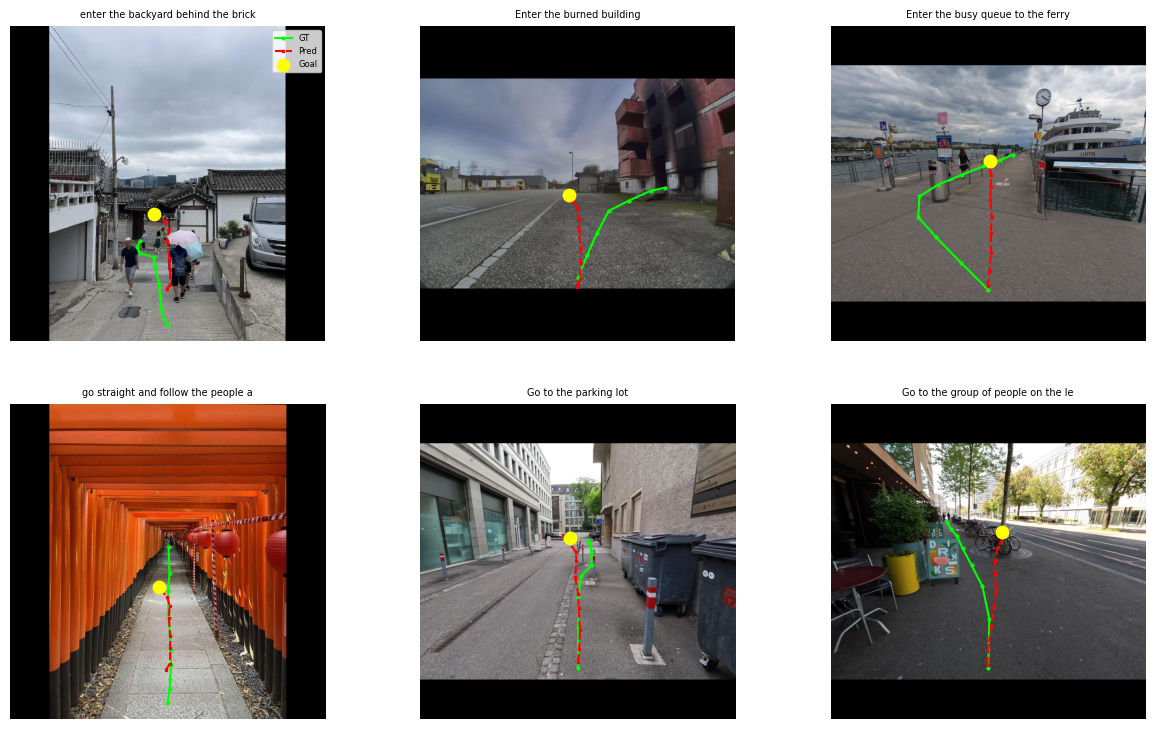

In [6]:
with torch.no_grad():
    goal_raw, trace_norm = model(val_joint.to(DEVICE))
    goal_raw   = goal_raw.cpu().numpy()
    trace_norm = trace_norm.cpu().numpy()

gm = goal_mean.numpy()
gs = goal_std.numpy()
goal_preds = np.clip(goal_raw * gs + gm, 0, 1)
 
def to_pixel(pred_norm, orig_w, orig_h):
    max_s  = max(orig_w, orig_h)
    x_off  = (max_s - orig_w) / 2
    y_off  = (max_s - orig_h) / 2
    p      = pred_norm.copy()
    p[:,0] = np.clip(p[:,0] * max_s - x_off, 0, orig_w - 1)
    p[:,1] = np.clip(p[:,1] * max_s - y_off, 0, orig_h - 1)
    return p

 
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, ax in enumerate(axes.flatten()):
    sample         = val_samples[i]
    img            = sample["image"].convert("RGB")
    orig_w, orig_h = img.size
    max_s          = max(orig_w, orig_h)
    x_off          = (max_s - orig_w) // 2
    y_off          = (max_s - orig_h) // 2

    canvas = np.zeros((max_s, max_s, 3), dtype=np.uint8)
    canvas[y_off:y_off+orig_h, x_off:x_off+orig_w] = np.array(img)
    ax.imshow(canvas)

    # GT traces
    for j, gt in enumerate(sample["ground_truth"][EMBODIMENT]):
        gt = np.array(gt)
        ax.plot(gt[:,0] + x_off, gt[:,1] + y_off,
                "o-", color="lime", lw=1.5, ms=2,
                label="GT" if j == 0 else None)

    # Predicted trace
    p = to_pixel(trace_norm[i], orig_w, orig_h)
    ax.plot(p[:,0] + x_off, p[:,1] + y_off,
            "s--", color="red", lw=1.5, ms=2, label="Pred")

    # Predicted goal
    gx = np.clip(goal_preds[i][0] * max_s - (max_s - orig_w) / 2, 0, orig_w - 1)
    gy = np.clip(goal_preds[i][1] * max_s - (max_s - orig_h) / 2, 0, orig_h - 1)
    ax.scatter(gx + x_off, gy + y_off, s=80, c="yellow", zorder=6, label="Goal")

    ax.set_title(sample["task"][:35], fontsize=7)
    ax.axis("off")
    if i == 0:
        ax.legend(fontsize=6, loc="upper right")